In [3]:
import pdfplumber
import os

pdf_path = "prod_spec/phone_specifications.pdf"
print(f"Target PDF: {pdf_path} (Exists: {os.path.exists(pdf_path)})")

Target PDF: prod_spec/phone_specifications.pdf (Exists: True)


In [4]:
with pdfplumber.open(pdf_path) as pdf:
    print(f"Total Pages: {len(pdf.pages)}")
    print(f"PDF Metadata: {pdf.metadata}")

Total Pages: 2
PDF Metadata: {}


In [5]:
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[0]
    
    # Standard layout-aware text extraction
    layout_text = page.extract_text(layout=True)
    print("--- Page 1: Layout-Preserved Text (First 600 chars) ---\n")
    print(layout_text[:600])

--- Page 1: Layout-Preserved Text (First 600 chars) ---

                                                                                  
                                                                                  
                                                                                  
                                                                                  
        iPhone 17 Pro                                                             
                                                                                  
        Brand: Apple                                                              
        Price: 1199


In [6]:
with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start=1):
        tables = page.extract_tables()
        print(f"\n[Page {page_num}] Detected {len(tables)} table(s):")
        
        for t_idx, table in enumerate(tables, start=1):
            print(f"\n  --- Table {t_idx} (Page {page_num}) ---")
            for row in table:
                # Print formatted table row
                print("  | " + " | ".join(str(cell or "").strip() for cell in row) + " |")


[Page 1] Detected 2 table(s):

  --- Table 1 (Page 1) ---
  | Specification | Details |
  | Category | Smartphones |
  | Display / Screen | 6.3" Super Retina XDR OLED, 120Hz ProMotion |
  | Processor / Hardware | A19 Pro Bionic Chip (3nm) |
  | Memory / Storage | 256GB storage |
  | Connectivity | Wi-Fi 7, Bluetooth 5.4, 5G |
  | Power / Battery | 4200mAh battery; 25W MagSafe |
  | Noise / Decibels | Not specified |
  | Dimensions & Weight | 187g |
  | Warranty | 1-Year Apple Warranty |

  --- Table 2 (Page 1) ---
  | Specification | Details |
  | Category | Smartphones |
  | Display / Screen | 6.8" Dynamic AMOLED 2X QHD+, 120Hz |
  | Processor / Hardware | Snapdragon 8 Gen 4 |
  | Memory / Storage | 12GB RAM, 512GB storage |

[Page 2] Detected 1 table(s):

  --- Table 1 (Page 2) ---
  | Specification | Details |
  | Connectivity | Wi-Fi 7, Bluetooth 5.4 |
  | Power / Battery | 5000mAh; 45W wired, 15W wireless |
  | Noise / Decibels | Not specified |
  | Dimensions & Weight | 219g |
 

In [7]:
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[0]
    
    # Identify large font characters (e.g. size >= 13pt)
    heading_lines = []
    current_line = []
    
    for char in page.chars:
        # print(char)
        if char.get("size", 0) >= 13:
            current_line.append(char["text"])
        elif current_line:
            text_segment = "".join(current_line).strip()
            if text_segment and text_segment not in heading_lines:
                heading_lines.append(text_segment)
            current_line = []
            
    print("Detected Section Headings / Titles (Font Size >= 13pt):")
    for h in heading_lines:
        print(f"- {h}")

Detected Section Headings / Titles (Font Size >= 13pt):
- iPhone 17 Pro
- Samsung Galaxy S25 Ultra


In [8]:
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[0]
    words = page.extract_words()
    
    print(f"Total Words on Page 1: {len(words)}\n")
    for w in words[:10]:
        print(w)

Total Words on Page 1: 223

{'text': 'iPhone', 'x0': 57.02362, 'x1': 100.36561999999999, 'top': 54.045400000000086, 'doctop': 54.045400000000086, 'bottom': 67.04540000000009, 'upright': True, 'height': 13.0, 'width': 43.34199999999999, 'direction': 'ltr'}
{'text': '17', 'x0': 103.97962, 'x1': 118.43561999999999, 'top': 54.045400000000086, 'doctop': 54.045400000000086, 'bottom': 67.04540000000009, 'upright': True, 'height': 13.0, 'width': 14.455999999999989, 'direction': 'ltr'}
{'text': 'Pro', 'x0': 122.04962, 'x1': 143.72062000000003, 'top': 54.045400000000086, 'doctop': 54.045400000000086, 'bottom': 67.04540000000009, 'upright': True, 'height': 13.0, 'width': 21.67100000000002, 'direction': 'ltr'}
{'text': 'Brand:', 'x0': 57.02362, 'x1': 87.63262, 'top': 75.32090000000005, 'doctop': 75.32090000000005, 'bottom': 84.82090000000005, 'upright': True, 'height': 9.5, 'width': 30.609, 'direction': 'ltr'}
{'text': 'Apple', 'x0': 90.27362, 'x1': 114.56512, 'top': 75.32090000000005, 'doctop': 7

In [9]:
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[0]
    width, height = page.width, page.height
    
    # Crop the top 120 points (Product title banner)
    bbox_width = (0, 0, width, 120)
    top_banner = page.crop(bbox_width)
    
    print("Cropped Top Banner Text -- ")
    print(top_banner.extract_text())

Cropped Top Banner Text -- 
iPhone 17 Pro
Brand: Apple
Price: 1199.00 USD
About this item:


In [10]:
with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start=1):
        print(f"Page {page_num} Vector Primitives:")
        print(f"- Lines      : {len(page.lines)}")
        print(f"- Rectangles : {len(page.rects)}")
        print(f"- Curves     : {len(page.curves)}")

Page 1 Vector Primitives:
- Lines      : 23
- Rectangles : 2
- Curves     : 0
Page 2 Vector Primitives:
- Lines      : 13
- Rectangles : 1
- Curves     : 0


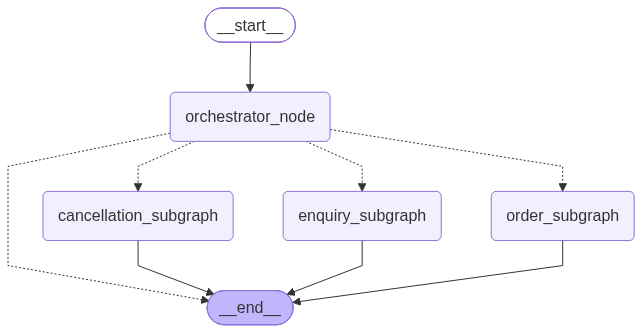

In [4]:
from IPython.display import Image, display
from app.graph import oms_graph

display(Image(oms_graph.get_graph().draw_mermaid_png()))